# Data Analysis

In this notebook I compare two machine learning models - a Random Forest and a
support vector machine for seizure detection using electroencephalogram (EEG) recordings. The process covers cleaning the data, training the models, comparing their performance across key metrics, and looking closely into what drives the high classification accuracy on one of the datasets.

The two datasets are analysed separately:

1. **BEED** (Bangalore EEG Epilepsy Dataset, UCI): 16 summary features,
   one per EEG channel, 8,000 recordings.
2. **ESR** (Epileptic Seizure Recognition, Kaggle): 178 EEG time points,
   11,500 recordings.

## Dataset sources

- **BEED** - Bangalore EEG Epilepsy Dataset, UCI Machine Learning Repository.
  https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset

- **ESR** - Epileptic Seizure Recognition, shared on Kaggle

  https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition)

The files I actually use are "BEED_Data.csv" and "Epileptic Seizure
Recognition.csv" downloaded from the links above.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harunshimanto/epileptic-seizure-recognition")

print("Path to dataset files:", path)

# Import the libraries



In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline


In [1]:
# Main models: Random Forest and SVM
# LogisticRegression is imported later, only for a diagnostic check
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_auc_score)

random_state = 42


# Load the data

For the ESR dataset there is an extra column called Unnamed that only holds
sample ID's from the original files. Those IDs are not EEG measurements and
can't be used to predict seizures, so I drop the column before training.



In [5]:
def data_path(filename):
    for base in ["data", "/content"]:
        path = os.path.join(base, filename)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        f"Could not find {filename} in ./data or /content")

beed = pd.read_csv(data_path("C:/Users/konda reddy/Downloads/Case-Studies-main/Case-Studies-main/individual-task-1/BEED_Data.csv"))
esr  = pd.read_csv(data_path("C:/Users/konda reddy/Downloads/Case-Studies-main/Case-Studies-main/individual-task-1/Epileptic Seizure Recognition.csv")).drop(columns=["Unnamed"])
print("BEED:", beed.shape, " | ESR:", esr.shape)


BEED: (8000, 17)  | ESR: (11500, 179)


# Understand the data

A quick look at the size, columns and target values


In [6]:
print("BEED shape (rows, columns):", beed.shape)
print("BEED columns:", beed.columns.tolist())

print("\nBEED class counts:")
print(beed["y"].value_counts().sort_index())


BEED shape (rows, columns): (8000, 17)
BEED columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']

BEED class counts:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [7]:
print("ESR shape (rows, columns):", esr.shape)
print("ESR column count:", len(esr.columns) - 1, "EEG time points + label")


ESR shape (rows, columns): (11500, 179)
ESR column count: 178 EEG time points + label


In [8]:
print("BEED original target (documented classes):")
print(beed["y"].value_counts().sort_index())


BEED original target (documented classes):
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [9]:
print("\nESR target:")
print(esr["y"].value_counts().sort_index())


ESR target:
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64


# Exploring the columns

I check the column names and value ranges to make sure I understand what each column holds before using


In [10]:
print("\nBEED descriptive stats (mean/std/min/max per channel):")
display(beed.select_dtypes("number").describe().T[["mean","std","min","max"]].round(2))


BEED descriptive stats (mean/std/min/max per channel):


,mean,std,min,max
X1,-1.49,36.82,-281.0,252.0
X2,-2.19,36.11,-255.0,261.0
X3,-3.24,35.80,-255.0,238.0
X4,-4.12,36.29,-257.0,246.0
X5,-1.82,37.62,-264.0,249.0
X6,-2.31,36.31,-277.0,245.0
X7,-3.40,36.36,-277.0,220.0
X8,-3.45,36.52,-260.0,271.0
X9,-1.65,38.11,-290.0,280.0
X10,-2.56,37.54,-302.0,251.0


In [11]:
print("ESR EEG values: range approx [%d, %d] (2047 values = ADC clipping)" %
      (esr.iloc[:, :-1].values.min(), esr.iloc[:, :-1].values.max()))

ESR EEG values: range approx [-1885, 2047] (2047 values = ADC clipping)


# Check data quality

Before modelling check for missing values, duplicate rows and the number of classes, so the data is clean enough to use

In [12]:
for name, df in [("BEED", beed), ("ESR", esr)]:
    print(f"{name}: missing={df.isna().sum().sum()}  duplicates={df.duplicated().sum()}")

BEED: missing=0  duplicates=0
ESR: missing=0  duplicates=0


# Feature matrix and target

The models need a feature matrix X and a target y. For the clinical question a
recording is either a seizure or not, so I turn the multi-class labels into a
yes/no target.

The mapping comes from the dataset documentation, not an assumption:

- **BEED**: 0 = healthy subjects (non-seizure); 1 = generalised seizures,
  2 = focal seizures, 3 = seizure events (all seizure).
        
  Binary target: y = 1 when the original label is not 0.
- **ESR**: 1 = seizure activity; 2 = tumor area, 3 = healthy brain area,
  4 = eyes closed, 5 = eyes open (all non-seizure).
   
  Binary target: y = 1 when the original label is 1.


In [13]:
beed = beed.copy(); esr = esr.copy()
beed_y_original = beed["y"].values
beed["y"] = (beed_y_original != 0).astype(int)
esr["y"] = (esr["y"] == 1).astype(int)

for name, df in [("BEED", beed), ("ESR", esr)]:
    print(f"{name}: X={df.shape[1]-1} features, y binary")


BEED: X=16 features, y binary
ESR: X=178 features, y binary


#Check Class Distribution

Check the split between seizure and non-seizure rows in both datasets.


In [14]:
for name, df in [("BEED", beed), ("ESR", esr)]:
    counts = df["y"].value_counts().sort_index()
    print(f"{name}: " + ", ".join(f"y={k} ({100*v/len(df):.1f}%)" for k, v in counts.items()))

BEED: y=0 (25.0%), y=1 (75.0%)
ESR: y=0 (80.0%), y=1 (20.0%)


# Training and test split

I split each dataset into 80% training and 20% testing. The split is
stratified so the class balance is the same in both sets and it uses a fixed
random seed (42) so the results can be reproduced exactly.


In [15]:
splits = {}
for name, df in [("BEED", beed), ("ESR", esr)]:
    X = df.drop(columns=["y"]).astype(float); y = df["y"].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)
    splits[name] = (X_train, X_test, y_train, y_test)
    print(f"{name}: train={len(X_train):,} test={len(X_test):,} | test {sum(y_test==1):,} seizure / {sum(y_test==0):,} non-seizure")

BEED: train=6,400 test=1,600 | test 1,200 seizure / 400 non-seizure
ESR: train=9,200 test=2,300 | test 460 seizure / 1,840 non-seizure


# Standardise the features

The features are measured in different scales, so I standardise them. The
scaler is fitted on the training set only and then applied to the test set, so
no test information is used during training. The SVM in particular needs this
because it works with distances between points.


In [16]:
for name, (X_train, X_test, y_train, y_test) in splits.items():
    scaler = StandardScaler().fit(X_train)
    splits[name] = (scaler.transform(X_train), scaler.transform(X_test), y_train, y_test)
    print(f"{name}: fitted mean={scaler.mean_[:2]}...")
print("The scaler is fitted on the training set only, so the test set is not used during preprocessing.")

BEED: fitted mean=[-1.400625   -2.11671875]...
ESR: fitted mean=[-12.49630435 -11.70076087]...
The scaler is fitted on the training set only, so the test set is not used during preprocessing.


# The two models

I compare two models: a **Random Forest** and an **SVM**.

- Random Forest: an ensemble of decision trees. It handles many features and
  non-linear patterns well and is quick to train.
- SVM: finds a separating boundary and can capture non-linear patterns
  through the RBF kernel.

Both use balanced class weights because the binary classes are uneven, and
both use the fixed random seed. I didn't tune hyperparameters.


In [17]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=random_state, n_jobs=-1),
    "SVM (RBF)":     SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=random_state),
}
print("Random Forest: 200 trees, balanced class weights, fully grown trees")
print("SVM: RBF kernel, C=1.0, gamma=scale, balanced class weights")

Random Forest: 200 trees, balanced class weights, fully grown trees
SVM: RBF kernel, C=1.0, gamma=scale, balanced class weights


# Training and evaluating the models

Fit each model on the training set and then score it on the test set. I report accuracy, balanced accuracy, precision, recall, F1 and the confusion matrix, because in a healthcare setting missing a seizure is the most serious error.


In [18]:
results = []

In [19]:
def evaluate(name, model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scores = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X_test))
    results.append({
        "dataset": name, "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, scores),
    })
    print("=" * 70)
    print(f"{name} | {model_name}")
    print(classification_report(y_test, predictions, target_names=["Non-seizure", "Seizure"], digits=4))
    conf_matrix = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = conf_matrix.ravel()
    print(f"False negatives : {fn}")
    print(f"False positives :     {fp}")
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(pd.DataFrame(conf_matrix, index=["actual: Non-seizure", "actual: Seizure"],
                       columns=["predicted: Non-seizure", "predicted: Seizure"]).to_string())
    fig, ax = plt.subplots(figsize=(4, 3.2))
    ConfusionMatrixDisplay(conf_matrix, display_labels=["Non-seizure", "Seizure"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"{model_name} - {name}")
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ', '_')}_{name}.png", dpi=150)
    plt.show()

BEED | Random Forest
              precision    recall  f1-score   support

 Non-seizure     1.0000    0.9900    0.9950       400
     Seizure     0.9967    1.0000    0.9983      1200

    accuracy                         0.9975      1600
   macro avg     0.9983    0.9950    0.9967      1600
weighted avg     0.9975    0.9975    0.9975      1600

False negatives : 0
False positives :     4
Confusion matrix (rows=actual, cols=predicted):
                     predicted: Non-seizure  predicted: Seizure
actual: Non-seizure                     396                   4
actual: Seizure                           0                1200


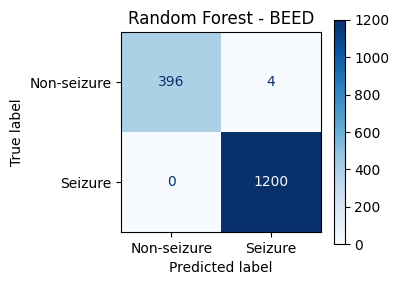

In [20]:
evaluate("BEED", "Random Forest", models["Random Forest"], *splits["BEED"])

BEED | SVM (RBF)
              precision    recall  f1-score   support

 Non-seizure     1.0000    0.9875    0.9937       400
     Seizure     0.9959    1.0000    0.9979      1200

    accuracy                         0.9969      1600
   macro avg     0.9979    0.9938    0.9958      1600
weighted avg     0.9969    0.9969    0.9969      1600

False negatives : 0
False positives :     5
Confusion matrix (rows=actual, cols=predicted):
                     predicted: Non-seizure  predicted: Seizure
actual: Non-seizure                     395                   5
actual: Seizure                           0                1200


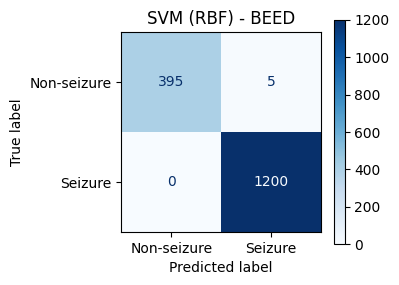

In [21]:
evaluate("BEED", "SVM (RBF)", models["SVM (RBF)"], *splits["BEED"])

ESR | Random Forest
              precision    recall  f1-score   support

 Non-seizure     0.9733    0.9924    0.9828      1840
     Seizure     0.9670    0.8913    0.9276       460

    accuracy                         0.9722      2300
   macro avg     0.9702    0.9418    0.9552      2300
weighted avg     0.9721    0.9722    0.9717      2300

False negatives : 50
False positives :     14
Confusion matrix (rows=actual, cols=predicted):
                     predicted: Non-seizure  predicted: Seizure
actual: Non-seizure                    1826                  14
actual: Seizure                          50                 410


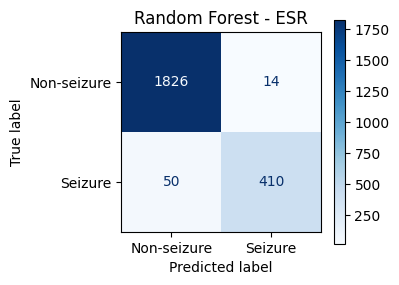

In [22]:
evaluate("ESR", "Random Forest", models["Random Forest"], *splits["ESR"])

ESR | SVM (RBF)
              precision    recall  f1-score   support

 Non-seizure     0.9912    0.9777    0.9844      1840
     Seizure     0.9155    0.9652    0.9397       460

    accuracy                         0.9752      2300
   macro avg     0.9533    0.9715    0.9620      2300
weighted avg     0.9760    0.9752    0.9755      2300

False negatives : 16
False positives :     41
Confusion matrix (rows=actual, cols=predicted):
                     predicted: Non-seizure  predicted: Seizure
actual: Non-seizure                    1799                  41
actual: Seizure                          16                 444


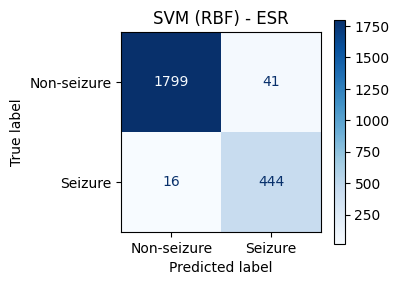

In [23]:
evaluate("ESR", "SVM (RBF)", models["SVM (RBF)"], *splits["ESR"])

# Results: comparing the two models




In [24]:
results_df = pd.DataFrame(results).round(4)
table = results_df.rename(columns={
    "accuracy": "Accuracy", "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision", "recall": "Recall",
    "f1": "F1", "roc_auc": "ROC-AUC"
})[["dataset", "model", "Accuracy", "Balanced Accuracy",
    "Precision", "Recall", "F1", "ROC-AUC"]]
display(table)
table.to_csv("model_results.csv", index=False)

,dataset,model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,BEED,Random Forest,0.9975,0.9950,0.9967,1.0000,0.9983,1.0000
1,BEED,SVM (RBF),0.9969,0.9938,0.9959,1.0000,0.9979,1.0000
2,ESR,Random Forest,0.9722,0.9418,0.9670,0.8913,0.9276,0.9970
3,ESR,SVM (RBF),0.9752,0.9715,0.9155,0.9652,0.9397,0.9955


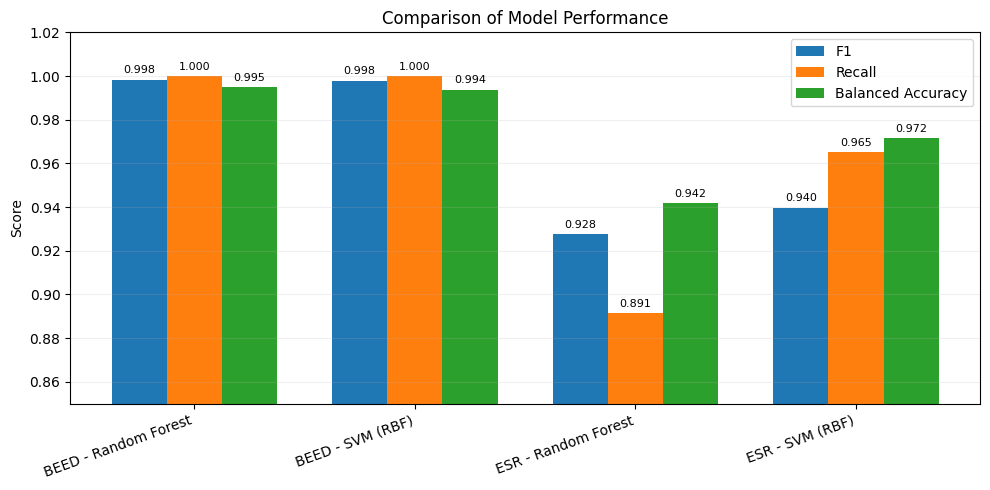

In [25]:
metrics = ["f1", "recall", "balanced_accuracy"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.25

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1) * width,
        results_df[metric],
        width,
        label=metric.replace("_", " ").title()
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )
ax.set_xticks(x)
ax.set_xticklabels(
    results_df["dataset"] + " - " + results_df["model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Score")
ax.set_title("Comparison of Model Performance")
ax.set_ylim(0.85, 1.02)

ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig("model_performance_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## How the two datasets compare

BEED and ESR are very different datasets, so I look at each one's strengths and limits.


In [26]:
for name in ["BEED", "ESR"]:
    dataset_rows = results_df[results_df["dataset"] == name]
    best = dataset_rows.loc[dataset_rows["f1"].idxmax()]
    print(f"{name}: best F1 {best['f1']:.3f} ({best['model']}) | AUC {best['roc_auc']:.3f} | "
          f"recall {best['recall']:.3f} | precision {best['precision']:.3f}")

BEED: best F1 0.998 (Random Forest) | AUC 1.000 | recall 1.000 | precision 0.997
ESR: best F1 0.940 (SVM (RBF)) | AUC 0.996 | recall 0.965 | precision 0.915


## Looking more closely at the BEED result

The BEED accuracy looks almost too good but I also checked how similar the rows are, whether the row order matches the
documented grouping and test a couple of explanations.

One important caution: these scores describe performance on this dataset's
test set only. They are not a prediction of performance on completely unseen
patients, because the dataset contains many very similar recordings and no
subject identifiers.


In [27]:
from sklearn.neighbors import NearestNeighbors

X_train, X_test, y_train, y_test = splits["BEED"]

nearest_neighbor = NearestNeighbors(n_neighbors=1)
nearest_neighbor.fit(X_train)

distances, _ = nearest_neighbor.kneighbors(X_test)

In [28]:
print("Distance from each BEED test recording to its closest training recording:")
print("Minimum:", distances.min())
print("Median:", np.median(distances))
print("Mean:", distances.mean())
print("Maximum:", distances.max())

for threshold in [1, 2, 5, 10]:
    print(
        f"Test rows with nearest training row <= {threshold}: "
        f"{(distances[:, 0] <= threshold).sum()} / {len(X_test)}"
    )

Distance from each BEED test recording to its closest training recording:
Minimum: 0.05400543994701241
Median: 0.21757670615121075
Mean: 0.7081969256716977
Maximum: 8.503026561937483
Test rows with nearest training row <= 1: 1207 / 1600
Test rows with nearest training row <= 2: 1388 / 1600
Test rows with nearest training row <= 5: 1591 / 1600
Test rows with nearest training row <= 10: 1600 / 1600


In [29]:
# The documentation says BEED rows are grouped into 200-recording blocks per subject
print("Rows per original class:")
print(pd.Series(beed_y_original).value_counts().sort_index())

expected_blocks = np.repeat(np.arange(4), 2000)
print("Row order matches the documented 2000-per-class blocks:",
      np.array_equal(beed_y_original, expected_blocks))

boundaries = np.flatnonzero(np.diff(beed_y_original) != 0) + 1
print("Class boundary row indices:", boundaries.tolist())

Rows per original class:
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64
Row order matches the documented 2000-per-class blocks: True
Class boundary row indices: [2000, 4000, 6000]


## Does holding out whole blocks change the BEED result?

The BEED documentation says the rows are grouped into 200-recording blocks per
subject, but the CSV has no subject-ID column. As a sensitivity check I hold
out whole 200-row blocks so very similar recordings are not split between the
training and test sets. This is a block-based check, not a true subject-level
split, because subject identifiers were unavailable.


In [30]:
X_values = beed.drop(columns=["y"]).values.astype(np.int32)
y_values = beed["y"].values
n_rows = len(X_values)

test_mask = np.zeros(n_rows, dtype=bool)
for class_label in range(4):
    test_mask[class_label*2000+1600: class_label*2000+2000] = True
train_mask = ~test_mask

print(f"Held out for testing: {int(test_mask.sum()):,} rows "
      f"({int(test_mask.sum()/4)} rows per class block)")
print(f"Used for training: {int(train_mask.sum()):,} rows")

Held out for testing: 1,600 rows (400 rows per class block)
Used for training: 6,400 rows


In [31]:
for model_name, model in [
    ("Random Forest", RandomForestClassifier(200, class_weight="balanced",
                                             random_state=random_state, n_jobs=-1)),
    ("SVM (RBF)", SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=random_state)),
]:
    scaler = StandardScaler().fit(X_values[train_mask])
    model.fit(scaler.transform(X_values[train_mask]), y_values[train_mask])
    predictions = model.predict(scaler.transform(X_values[test_mask]))
    print(f"{model_name}: block-split accuracy "
          f"{accuracy_score(y_values[test_mask], predictions):.4f} "
          f"(random 80/20 split: 0.9975 / 0.9969)")
print("The block-based sensitivity check produced similarly high performance, but it")
print("cannot replace a true subject-level split because subject IDs were unavailable.")

Random Forest: block-split accuracy 0.9962 (random 80/20 split: 0.9975 / 0.9969)
SVM (RBF): block-split accuracy 0.9969 (random 80/20 split: 0.9975 / 0.9969)
The block-based sensitivity check produced similarly high performance, but it
cannot replace a true subject-level split because subject IDs were unavailable.


## Can a single simple feature explain the result?

As a final check I test whether a single simple feature could explain the high score.

In [32]:
from sklearn.linear_model import LogisticRegression

mean_amp = beed.drop(columns=["y"]).values.mean(axis=1).reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(mean_amp, beed["y"].values, test_size=0.2,
                                                    stratify=beed["y"].values, random_state=random_state)
log_reg = LogisticRegression().fit(X_train, y_train)
predictions = log_reg.predict(X_test)
print(f"Logistic regression on 1 feature (mean channel amplitude): "
      f"accuracy {accuracy_score(y_test, predictions):.4f} | F1 {f1_score(y_test, predictions):.3f} | "
      f"AUC {roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]):.4f}")
print("Mean amplitude alone produced substantially lower performance, which suggests")
print("that information beyond this single summary feature contributes to the classification.")

Logistic regression on 1 feature (mean channel amplitude): accuracy 0.8100 | F1 0.888 | AUC 0.6150
Mean amplitude alone produced substantially lower performance, which suggests
that information beyond this single summary feature contributes to the classification.


# Summary

The two datasets give useful and complementary insights, and both models performed strongly on both of them, although accuracy was higher on BEED than
on ESR.

On BEED the observed test results were close to perfect: Random Forest reached
an F1-score of 0.998 and the SVM 0.998. This still held in the block-based
sensitivity check and a single mean-amplitude feature only reached 81%
accuracy with an AUC of 0.615, so the strong result is not explained by one
easy feature.

On ESR the results were lower but still strong: Random Forest reached an
F1-score of 0.928 with a recall of 0.891, while the SVM reached 0.940 with a
recall of 0.965. The SVM missed fewer seizures but raised more false alarms,
whereas the Random Forest raised fewer false alarms but missed more seizures.

The evaluation metrics were chosen for the healthcare context. Recall is
important because missing a seizure is more serious than an occasional false
alarm, balanced accuracy handles the unequal class sizes  and the F1-score
brings precision and recall together. The confusion matrices make the
false-positive and false-negative pattern visible.

There are limits to what the BEED result can claim. It contains many very
similar recordings and has no subject IDs, so the near-perfect score should
not be read as performance on completely unseen patients. Testing on new,
unseen patients would be needed before drawing any clinical conclusions.


In [44]:
# -------------------------------------------------
# Fairness Analysis – EEG Seizure Detection
# Computes group-wise balanced accuracy & prediction rates
# -------------------------------------------------
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

for ds_name, csv_file in [("BEED", "BEED_Data.csv"), ("ESR", "Epileptic Seizure Recognition.csv")]:
    print(f"\n=== {ds_name} ===")
    
    # --- Load & preprocess (matching Task 1) ---
    if ds_name == "BEED":
        df = pd.read_csv(csv_file)
        y_bin = (df["y"].values != 0).astype(int)    # 0=non-seizure, 1=seizure
        y_sens = df["y"].values                       # original 0,1,2,3 classes
        X = df.drop(columns=["y"]).astype(float)
    else:  # ESR
        df = pd.read_csv(csv_file).drop(columns=["Unnamed"], errors="ignore")
        y_bin = (df["y"].values == 1).astype(int)    # 1=seizure activity
        y_sens = df["y"].values                       # original 1,2,3,4,5 labels
        X = df.drop(columns=["y"]).astype(float)
    
    # --- Train/test split ---
    Xtr, Xte, ytr, yte = train_test_split(X, y_bin, test_size=0.2,
                                          stratify=y_bin, random_state=42)
    
    # --- Train models ---
    rf = RandomForestClassifier(200, class_weight="balanced", random_state=42, n_jobs=-1).fit(Xtr, ytr)
    yhat_rf = rf.predict(Xte)
    ba_rf = balanced_accuracy_score(yte, yhat_rf)
    
    sc = StandardScaler().fit(Xtr)
    svm = SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42).fit(sc.transform(Xtr), ytr)
    yhat_svm = svm.predict(sc.transform(Xte))
    ba_svm = balanced_accuracy_score(yte, yhat_svm)
    
    # --- Print fairness metrics by sensitive group ---
    groups = np.unique(y_sens[Xte.index])
    print(f"Test set: {len(yte)} samples | Groups: {list(groups)}")
    print(f"  Balanced accuracy: RF {ba_rf:.3f} | SVM {ba_svm:.3f}")
    
    for model_name, yhat in [("RF", yhat_rf), ("SVM", yhat_svm)]:
        print(f"  {model_name} positive prediction rate by group:")
        for g in sorted(groups):
            mask = y_sens[Xte.index] == g
            n = mask.sum()
            if n > 0:
                pos_rate = (yhat[mask] == 1).mean()
                print(f"    Group {g}: {n} samples, pos rate = {pos_rate:.3f}")


=== BEED ===
Test set: 1600 samples | Groups: [0, 1, 2, 3]
  Balanced accuracy: RF 0.995 | SVM 0.994
  RF positive prediction rate by group:
    Group 0: 400 samples, pos rate = 0.010
    Group 1: 406 samples, pos rate = 1.000
    Group 2: 391 samples, pos rate = 1.000
    Group 3: 403 samples, pos rate = 1.000
  SVM positive prediction rate by group:
    Group 0: 400 samples, pos rate = 0.013
    Group 1: 406 samples, pos rate = 1.000
    Group 2: 391 samples, pos rate = 1.000
    Group 3: 403 samples, pos rate = 1.000

=== ESR ===
Test set: 2300 samples | Groups: [1, 2, 3, 4, 5]
  Balanced accuracy: RF 0.941 | SVM 0.971
  RF positive prediction rate by group:
    Group 1: 460 samples, pos rate = 0.889
    Group 2: 450 samples, pos rate = 0.024
    Group 3: 467 samples, pos rate = 0.006
    Group 4: 471 samples, pos rate = 0.000
    Group 5: 452 samples, pos rate = 0.000
  SVM positive prediction rate by group:
    Group 1: 460 samples, pos rate = 0.965
    Group 2: 450 samples, pos 

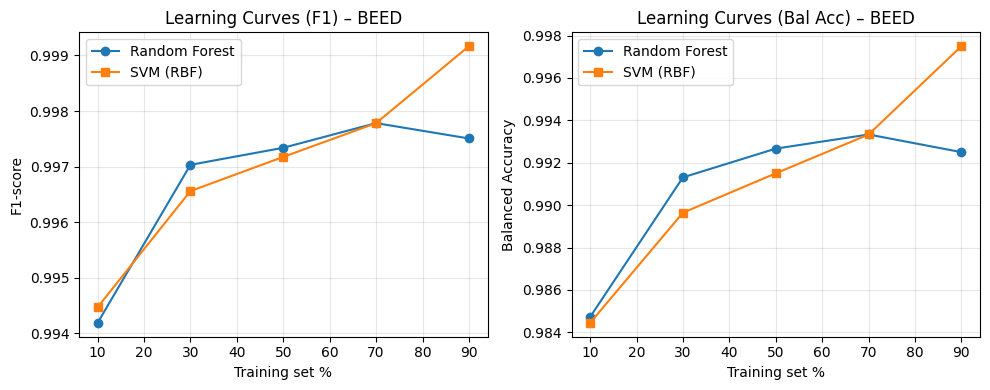

BEED: RF F1=0.998 | SVM F1=0.999
BEED: RF BalAcc=0.992 | SVM BalAcc=0.998


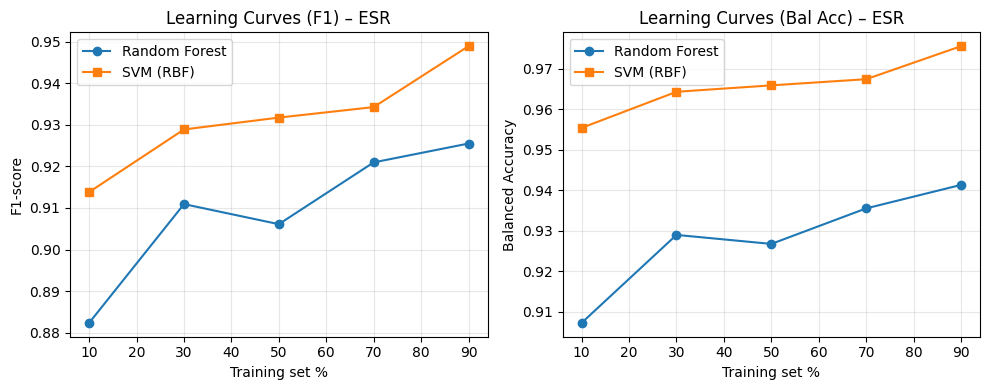

ESR: RF F1=0.926 | SVM F1=0.949
ESR: RF BalAcc=0.941 | SVM BalAcc=0.976


In [47]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score

for ds in ["BEED", "ESR"]:
    if ds == "BEED": 
        df = pd.read_csv("BEED_Data.csv"); df["y"] = (df["y"]!=0).astype(int)
    else: 
        df = pd.read_csv("Epileptic Seizure Recognition.csv").drop(columns=["Unnamed"], errors="ignore")
        df["y"] = (df["y"]==1).astype(int)
    
    X = df.drop(columns=["y"]).astype(float); y = df["y"].astype(int)
    
    train_sizes = np.linspace(0.1, 0.9, 5)  # 0.1, 0.3, 0.5, 0.7, 0.9
    rf_f1, svm_f1 = [], []
    rf_bal, svm_bal = [], []
    
    for sz in train_sizes:
        Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=sz, stratify=y, random_state=42)
                # Random Forest
        rf = RandomForestClassifier(200, class_weight="balanced", random_state=42, n_jobs=-1).fit(Xtr, ytr)
        yhat_rf = rf.predict(Xte)
        rf_f1.append(f1_score(yte, yhat_rf))
        rf_bal.append(balanced_accuracy_score(yte, yhat_rf))
        
        # SVM
        sc = StandardScaler().fit(Xtr)
        svm = SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42).fit(sc.transform(Xtr), ytr)
        yhat_svm = svm.predict(sc.transform(Xte))
        svm_f1.append(f1_score(yte, yhat_svm))
        svm_bal.append(balanced_accuracy_score(yte, yhat_svm))
    
    # Plot F1-score
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_sizes*100, rf_f1, "o-", label="Random Forest")
    plt.plot(train_sizes*100, svm_f1, "s-", label="SVM (RBF)")
    plt.xlabel("Training set %"); plt.ylabel("F1-score"); plt.legend()
    plt.title(f"Learning Curves (F1) – {ds}"); plt.grid(alpha=0.3)
    
    # Plot Balanced Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_sizes*100, rf_bal, "o-", label="Random Forest")
    plt.plot(train_sizes*100, svm_bal, "s-", label="SVM (RBF)")
    plt.xlabel("Training set %"); plt.ylabel("Balanced Accuracy"); plt.legend()
    plt.title(f"Learning Curves (Bal Acc) – {ds}"); plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"learning_curves_{ds}.png", dpi=150)
    plt.show()
    
    print(f"{ds}: RF F1={rf_f1[-1]:.3f} | SVM F1={svm_f1[-1]:.3f}")
    print(f"{ds}: RF BalAcc={rf_bal[-1]:.3f} | SVM BalAcc={svm_bal[-1]:.3f}")
        



=== BEED DEBUG ===
Test set size: 1600 | Groups: [0, 1, 2, 3]
Overall: RF pos rate = 0.752, SVM pos rate = 0.753
  Group 0: n=400 | true seizure%=0.00 | RF pred%=0.010 | SVM pred%=0.013
  Group 1: n=406 | true seizure%=1.00 | RF pred%=1.000 | SVM pred%=1.000
  Group 2: n=391 | true seizure%=1.00 | RF pred%=1.000 | SVM pred%=1.000
  Group 3: n=403 | true seizure%=1.00 | RF pred%=1.000 | SVM pred%=1.000


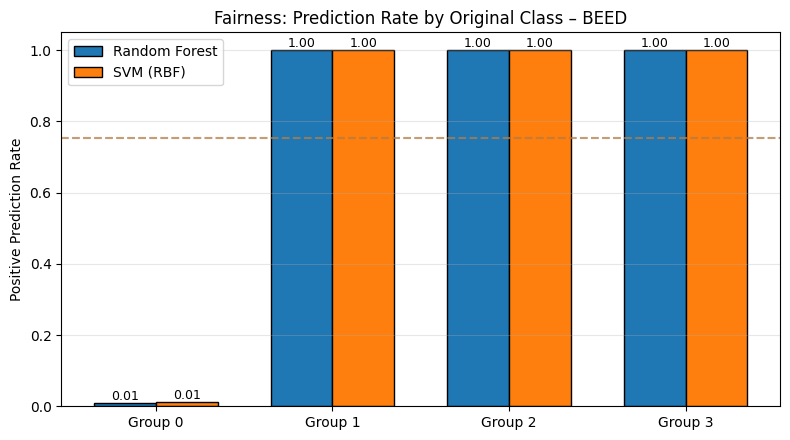


=== ESR DEBUG ===
Test set size: 2300 | Groups: [1, 2, 3, 4, 5]
Overall: RF pos rate = 0.184, SVM pos rate = 0.211
  Group 1: n=460 | true seizure%=1.00 | RF pred%=0.889 | SVM pred%=0.965
  Group 2: n=450 | true seizure%=0.00 | RF pred%=0.024 | SVM pred%=0.073
  Group 3: n=467 | true seizure%=0.00 | RF pred%=0.006 | SVM pred%=0.015
  Group 4: n=471 | true seizure%=0.00 | RF pred%=0.000 | SVM pred%=0.002
  Group 5: n=452 | true seizure%=0.00 | RF pred%=0.000 | SVM pred%=0.000


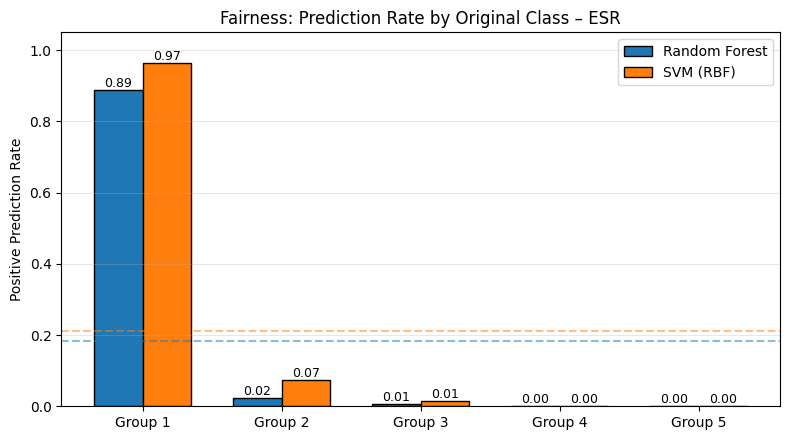

In [49]:
# -------------------------------------------------
# Debug Fairness – Check group sizes & predictions first
# -------------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

for ds_name, csv_file in [("BEED", "BEED_Data.csv"), ("ESR", "Epileptic Seizure Recognition.csv")]:
    print(f"\n=== {ds_name} DEBUG ===")
    
    if ds_name == "BEED":
        df = pd.read_csv(csv_file)
        y_bin = (df["y"].values != 0).astype(int)
        y_sens = df["y"].values
        X = df.drop(columns=["y"]).astype(float)
    else:
        df = pd.read_csv(csv_file).drop(columns=["Unnamed"], errors="ignore")
        y_bin = (df["y"].values == 1).astype(int)
        y_sens = df["y"].values
        X = df.drop(columns=["y"]).astype(float)
    
    Xtr, Xte, ytr, yte = train_test_split(X, y_bin, test_size=0.2, 
                                          stratify=y_bin, random_state=42)
    
    rf = RandomForestClassifier(200, class_weight="balanced", random_state=42, n_jobs=-1).fit(Xtr, ytr)
    yhat_rf = rf.predict(Xte)
    
    sc = StandardScaler().fit(Xtr)
    svm = SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42).fit(sc.transform(Xtr), ytr)
    yhat_svm = svm.predict(sc.transform(Xte))
    
    # --- DEBUG: Print group composition & predictions ---
    groups = sorted(np.unique(y_sens[Xte.index]))
    print(f"Test set size: {len(yte)} | Groups: {groups}")
    print(f"Overall: RF pos rate = {(yhat_rf==1).mean():.3f}, SVM pos rate = {(yhat_svm==1).mean():.3f}")
    
    for g in groups:
        mask = y_sens[Xte.index] == g
        n = mask.sum()
        if n > 0:
            rf_pos = (yhat_rf[mask] == 1).mean()
            svm_pos = (yhat_svm[mask] == 1).mean()
            true_pos = (yte[mask] == 1).mean()
            print(f"  Group {g}: n={n:3d} | true seizure%={true_pos:.2f} | RF pred%={rf_pos:.3f} | SVM pred%={svm_pos:.3f}")
        else:
            print(f"  Group {g}: NO TEST SAMPLES")
    
    # --- Now plot only groups that have samples ---
    valid_groups = [g for g in groups if (y_sens[Xte.index] == g).sum() > 0]
    x_pos = np.arange(len(valid_groups))
    width = 0.35
    
    rf_rates = [(yhat_rf[y_sens[Xte.index] == g] == 1).mean() for g in valid_groups]
    svm_rates = [(yhat_svm[y_sens[Xte.index] == g] == 1).mean() for g in valid_groups]
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x_pos - width/2, rf_rates, width, label="Random Forest", color="#1f77b4", edgecolor="black")
    ax.bar(x_pos + width/2, svm_rates, width, label="SVM (RBF)", color="#ff7f0e", edgecolor="black")
    
    ax.axhline((yhat_rf == 1).mean(), color="#1f77b4", linestyle="--", alpha=0.5)
    ax.axhline((yhat_svm == 1).mean(), color="#ff7f0e", linestyle="--", alpha=0.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"Group {g}" for g in valid_groups])
    ax.set_ylabel("Positive Prediction Rate")
    ax.set_title(f"Fairness: Prediction Rate by Original Class – {ds_name}")
    ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1.05)
    
    for bars in ax.containers:
        ax.bar_label(bars, fmt="%.2f", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"fairness_{ds_name}.png", dpi=150)
    plt.show()

In [50]:
# After the ESR loop, add:
for g in sorted(np.unique(y_sens[Xte.index])):
    mask = y_sens[Xte.index] == g
    if mask.sum() > 0:
        true_pos = (yte[mask] == 1).mean()
        rf_pos = (yhat_rf[mask] == 1).mean()
        svm_pos = (yhat_svm[mask] == 1).mean()
        print(f"  Group {g}: n={mask.sum():3d} | true={true_pos:.2f} | RF={rf_pos:.3f} | SVM={svm_pos:.3f}")

  Group 1: n=460 | true=1.00 | RF=0.889 | SVM=0.965
  Group 2: n=450 | true=0.00 | RF=0.024 | SVM=0.073
  Group 3: n=467 | true=0.00 | RF=0.006 | SVM=0.015
  Group 4: n=471 | true=0.00 | RF=0.000 | SVM=0.002
  Group 5: n=452 | true=0.00 | RF=0.000 | SVM=0.000


In [56]:
# -------------------------------------------------
# Cross-Validation Analysis – EEG Seizure Detection
# 5-fold Stratified Cross-Validation
# -------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for ds in ["BEED", "ESR"]:

    print(f"\n{'='*50}")
    print(f"=== 5-Fold Cross-Validation: {ds} ===")
    print(f"{'='*50}")

    # --- Load & preprocess ---
    if ds == "BEED":
        df = pd.read_csv("BEED_Data.csv")
        df["y"] = (df["y"] != 0).astype(int)

    else:
        df = pd.read_csv(
            "Epileptic Seizure Recognition.csv"
        ).drop(columns=["Unnamed"], errors="ignore")
        df["y"] = (df["y"] == 1).astype(int)

    X = df.drop(columns=["y"]).astype(float)
    y = df["y"].astype(int)

    # --- Define models ---
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    # Pipeline prevents data leakage:
    # StandardScaler is fitted separately inside each CV fold
    svm = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            class_weight="balanced",
            random_state=42
        ))
    ])

    # --- Evaluation metrics ---
    scoring = {
        "F1": make_scorer(f1_score),
        "Balanced Accuracy": make_scorer(
            balanced_accuracy_score
        )
    }

    # --- Cross-validation ---
    for model_name, model in [
        ("Random Forest", rf),
        ("SVM", svm)
    ]:

        results = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        f1_scores = results["test_F1"]
        bal_scores = results["test_Balanced Accuracy"]

        print(f"\n{model_name}")

        print(
            f"  F1: "
            f"{f1_scores.mean():.3f} "
            f"+/- {f1_scores.std():.3f}"
        )

        print(
            f"  Balanced Accuracy: "
            f"{bal_scores.mean():.3f} "
            f"+/- {bal_scores.std():.3f}"
        )

        print(
            f"  Fold F1 scores: "
            f"{np.round(f1_scores, 3)}"
        )

        print(
            f"  Fold Balanced Accuracy: "
            f"{np.round(bal_scores, 3)}"
        )


=== 5-Fold Cross-Validation: BEED ===

Random Forest
  F1: 0.999 +/- 0.001
  Balanced Accuracy: 0.996 +/- 0.002
  Fold F1 scores: [1.    0.999 0.999 0.999 0.998]
  Fold Balanced Accuracy: [0.999 0.996 0.998 0.998 0.992]

SVM
  F1: 0.998 +/- 0.001
  Balanced Accuracy: 0.994 +/- 0.002
  Fold F1 scores: [0.999 0.998 0.998 0.998 0.997]
  Fold Balanced Accuracy: [0.998 0.994 0.994 0.995 0.991]

=== 5-Fold Cross-Validation: ESR ===

Random Forest
  F1: 0.920 +/- 0.005
  Balanced Accuracy: 0.937 +/- 0.004
  Fold F1 scores: [0.925 0.916 0.92  0.914 0.926]
  Fold Balanced Accuracy: [0.94  0.935 0.94  0.93  0.939]

SVM
  F1: 0.939 +/- 0.005
  Balanced Accuracy: 0.969 +/- 0.003
  Fold F1 scores: [0.945 0.944 0.933 0.936 0.934]
  Fold Balanced Accuracy: [0.974 0.97  0.967 0.967 0.966]


In [57]:
# 1. Add return_train_score=True to detect overfitting
results = cross_validate(
    model, X, y, cv=cv, scoring=scoring,
    n_jobs=-1,
    return_train_score=True  # ADD THIS
)

# 2. Print train scores to check overfitting
print(f"  Train F1: {results['train_F1'].mean():.3f} +/- {results['train_F1'].std():.3f}")
print(f"  Test  F1: {results['test_F1'].mean():.3f} +/- {results['test_F1'].std():.3f}")

# 3. For BEED: add return_estimator=True to inspect feature importance per fold
# results = cross_validate(..., return_estimator=True)

# 4. Consider 10-fold for BEED (8000 samples → 800/test fold is plenty)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # BEED
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # ESR (smaller)

  Train F1: 0.957 +/- 0.001
  Test  F1: 0.939 +/- 0.005
